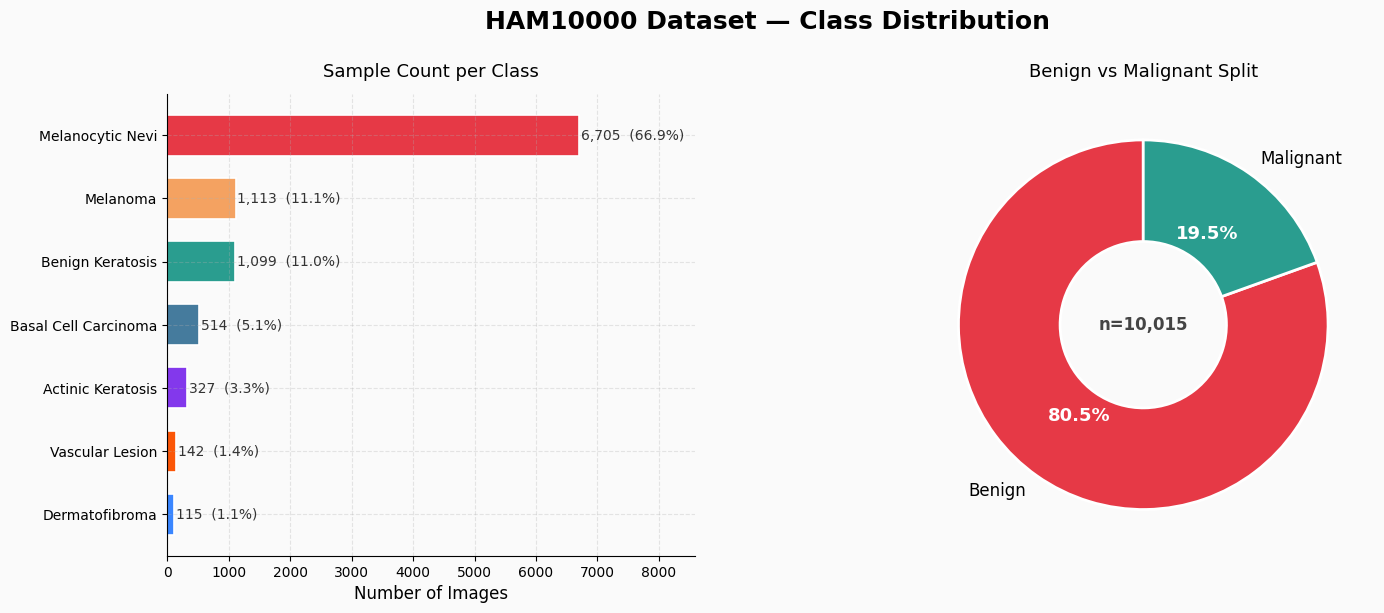

✅ Saved: fig1_class_distribution.png


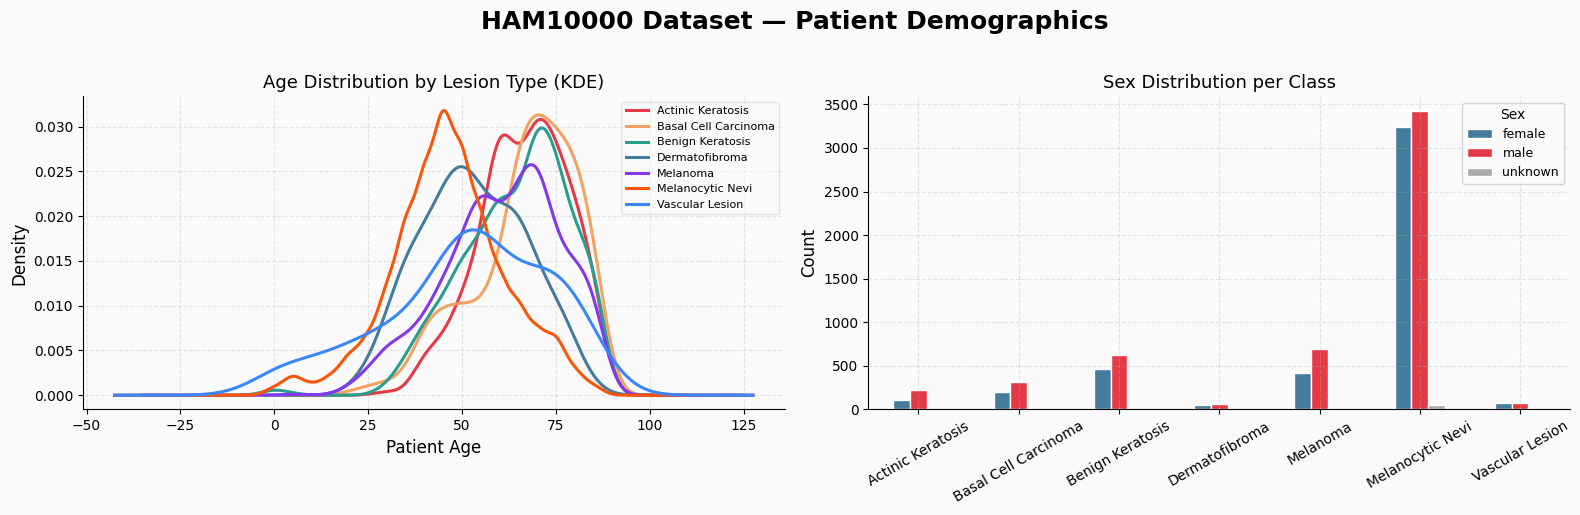

✅ Saved: fig2_demographics.png


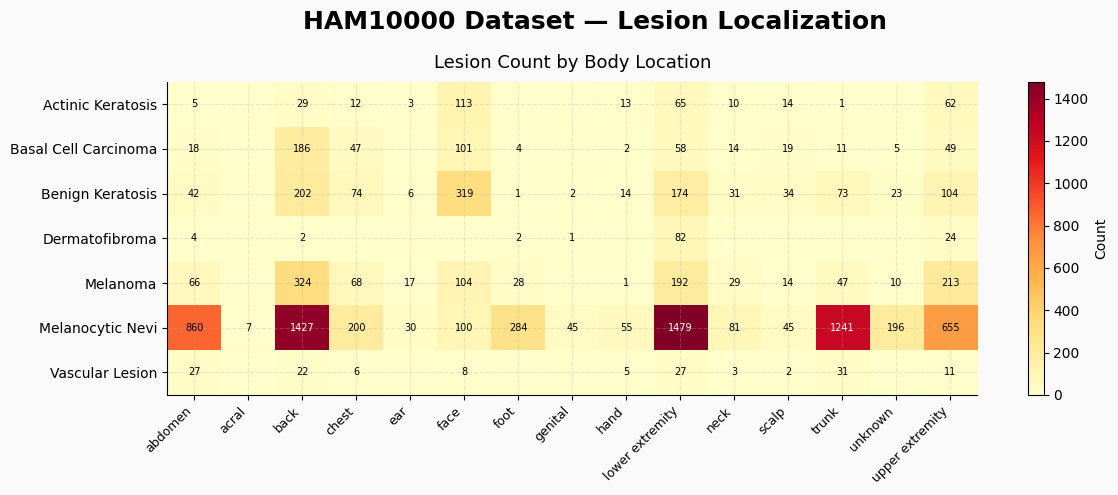

✅ Saved: fig3_localization.png


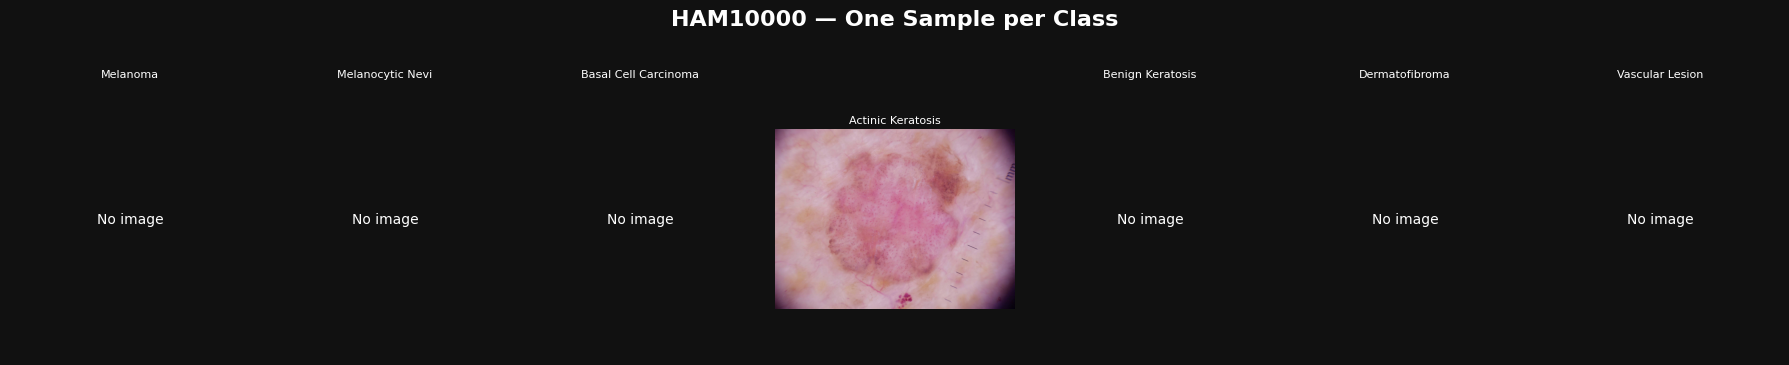

✅ Saved: fig4_sample_images.png

🎉 All figures saved! Use fig1 and fig4 for your slides proposal.


In [4]:
"""
HAM10000 Beautiful EDA Visualizations
For use in Kaggle Notebook or Google Colab
Author: ECE 284 Final Project
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# ── Color palette ──────────────────────────────────────────────────────────────
PALETTE = [
    "#E63946", "#F4A261", "#2A9D8F", "#457B9D",
    "#8338EC", "#FB5607", "#3A86FF"
]

LABEL_MAP = {
    'mel':  'Melanoma',
    'nv':   'Melanocytic Nevi',
    'bcc':  'Basal Cell Carcinoma',
    'akiec':'Actinic Keratosis',
    'bkl':  'Benign Keratosis',
    'df':   'Dermatofibroma',
    'vasc': 'Vascular Lesion'
}

MALIGNANT = {'mel', 'bcc', 'akiec'}

plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
})

# ── Load data ──────────────────────────────────────────────────────────────────
# Kaggle path — adjust if running locally
CSV_PATH = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
IMG_DIR  = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1'

df = pd.read_csv(CSV_PATH)
df['label']     = df['dx'].map(LABEL_MAP)
df['malignant'] = df['dx'].apply(lambda x: 'Malignant' if x in MALIGNANT else 'Benign')


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Class Distribution (bar + donut side by side)
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 6), facecolor='#FAFAFA')
fig.suptitle('HAM10000 Dataset — Class Distribution', fontsize=18,
             fontweight='bold', y=1.02)

gs = GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Bar chart ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
counts  = df['dx'].value_counts()
labels  = [LABEL_MAP[k] for k in counts.index]
colors  = [PALETTE[i % len(PALETTE)] for i in range(len(counts))]

bars = ax1.barh(labels[::-1], counts.values[::-1],
                color=colors[::-1], edgecolor='white', linewidth=1.2, height=0.65)

for bar, val in zip(bars, counts.values[::-1]):
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{val:,}  ({val/len(df)*100:.1f}%)',
             va='center', fontsize=10, color='#333')

ax1.set_xlabel('Number of Images', fontsize=12)
ax1.set_title('Sample Count per Class', fontsize=13, pad=12)
ax1.set_xlim(0, counts.max() * 1.28)

# ── Donut: benign vs malignant ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
bm   = df['malignant'].value_counts()
wcol = ['#E63946', '#2A9D8F']
wedges, texts, autotexts = ax2.pie(
    bm.values, labels=bm.index, autopct='%1.1f%%',
    colors=wcol, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
    at.set_color('white')

ax2.set_title('Benign vs Malignant Split', fontsize=13, pad=12)
centre = plt.Circle((0, 0), 0.40, color='#FAFAFA')
ax2.add_patch(centre)
ax2.text(0, 0, f'n={len(df):,}', ha='center', va='center',
         fontsize=12, fontweight='bold', color='#444')

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
print("✅ Saved: fig1_class_distribution.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Age & Sex Distribution
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor='#FAFAFA')
fig.suptitle('HAM10000 Dataset — Patient Demographics', fontsize=18,
             fontweight='bold', y=1.02)

# Age histogram by class
ax = axes[0]
for i, (dx, grp) in enumerate(df.groupby('dx')):
    grp['age'].dropna().plot.kde(ax=ax, color=PALETTE[i % len(PALETTE)],
                                  label=LABEL_MAP[dx], linewidth=2.2)
ax.set_xlabel('Patient Age', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Age Distribution by Lesion Type (KDE)', fontsize=13)
ax.legend(fontsize=8, framealpha=0.5)

# Sex distribution grouped bar
ax2 = axes[1]
sex_dx = df.groupby(['dx', 'sex']).size().unstack(fill_value=0)
sex_dx.index = [LABEL_MAP[k] for k in sex_dx.index]
sex_dx.plot(kind='bar', ax=ax2, color=['#457B9D', '#E63946', '#aaa'],
            edgecolor='white', linewidth=1)
ax2.set_xlabel('')
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Sex Distribution per Class', fontsize=13)
ax2.tick_params(axis='x', rotation=30)
ax2.legend(title='Sex', fontsize=9)

plt.tight_layout()
plt.savefig('fig2_demographics.png', dpi=180, bbox_inches='tight')
plt.show()
print("✅ Saved: fig2_demographics.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Localization heatmap (body location)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5), facecolor='#FAFAFA')
fig.suptitle('HAM10000 Dataset — Lesion Localization', fontsize=18,
             fontweight='bold')

loc_dx = (df.groupby(['dx', 'localization'])
            .size()
            .unstack(fill_value=0))
loc_dx.index = [LABEL_MAP[k] for k in loc_dx.index]

im = ax.imshow(loc_dx.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(loc_dx.columns)))
ax.set_xticklabels(loc_dx.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(loc_dx.index)))
ax.set_yticklabels(loc_dx.index, fontsize=10)

for i in range(len(loc_dx.index)):
    for j in range(len(loc_dx.columns)):
        val = loc_dx.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=7, color='black' if val < loc_dx.values.max()*0.6 else 'white')

plt.colorbar(im, ax=ax, label='Count')
ax.set_title('Lesion Count by Body Location', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('fig3_localization.png', dpi=180, bbox_inches='tight')
plt.show()
print("✅ Saved: fig3_localization.png")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Sample images grid (one per class)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 7, figsize=(18, 3.5), facecolor='#111')
fig.suptitle('HAM10000 — One Sample per Class', fontsize=16,
             fontweight='bold', color='white', y=1.03)

for ax, (dx, label) in zip(axes, LABEL_MAP.items()):
    sample_id = df[df['dx'] == dx].sample(1)['image_id'].values[0]
    img_path  = os.path.join(IMG_DIR, sample_id + '.jpg')
    try:
        img = Image.open(img_path)
        ax.imshow(img)
    except:
        ax.text(0.5, 0.5, 'No image', ha='center', va='center',
                transform=ax.transAxes, color='white')
    ax.set_title(label, fontsize=8, color='white', pad=4, wrap=True)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE[list(LABEL_MAP).index(dx)])
        spine.set_linewidth(3)

plt.tight_layout()
plt.savefig('fig4_sample_images.png', dpi=180, bbox_inches='tight',
            facecolor='#111')
plt.show()
print("✅ Saved: fig4_sample_images.png")


print("\n🎉 All figures saved! Use fig1 and fig4 for your slides proposal.")